# MyAnimeList 2025 - ML Analysis & Recommendation System
# Задача: построение модели для предсказания рейтинга аниме и система рекомендаций


# УСТАНОВКА НЕОБХОДИМЫХ БИБЛИОТЕК



In [26]:
!pip install kagglehub scikit-learn xgboost lightgbm optuna shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.9 MB/s eta 0:00:00


# ИМПОРТЫ

In [27]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings('ignore')

# Фиксация random_state для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("syahrulapriansyah2/myanimelist-2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'myanimelist-2025' dataset.
Path to dataset files: /kaggle/input/myanimelist-2025


# ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

In [32]:
print("=" * 80)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

# Загрузка датасета
path = kagglehub.dataset_download("syahrulapriansyah2/myanimelist-2025")
print(f"Путь к данным: {path}\n")

# Чтение данных
df = pd.read_csv(f"{path}/mal_anime.csv")

print(f"Размер датасета: {df.shape}")
print(f"\nПервые строки:\n{df.head()}")
print(f"\nИнформация о данных:\n{df.info()}")
print(f"\nСтатистика:\n{df.describe()}")
print(f"\nПропущенные значения:\n{df.isnull().sum()}")

ЗАГРУЗКА ДАННЫХ
Using Colab cache for faster access to the 'myanimelist-2025' dataset.
Путь к данным: /kaggle/input/myanimelist-2025

Размер датасета: (19931, 25)

Первые строки:
   myanimelist_id                            title  \
0               1                     Cowboy Bebop   
1               5  Cowboy Bebop: Tengoku no Tobira   
2               6                           Trigun   
3               7               Witch Hunter Robin   
4               8                   Bouken Ou Beet   

                                         description  \
0  Crime is timeless. By the year 2071, humanity ...   
1  Another day, another bounty—such is the life o...   
2  Vash the Stampede is the man with a $$60,000,0...   
3  Though hidden away from the general public, Wi...   
4  It is the dark century and the people are suff...   

                                               image   Type Episodes  \
0  https://cdn.myanimelist.net/images/anime/4/196...     TV       26   
1  https://cdn.

# ПРЕДОБРАБОТКА ДАННЫХ

In [44]:
print("\n" + "=" * 80)
print("ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 80)

# Создаем копию для работы
df_clean = df.copy()

# Определяем целевую переменную - будем предсказывать Score (рейтинг аниме)
# Это логичная задача для регрессии в контексте аниме
target_column = 'Score'

# Удаляем строки с пропущенным таргетом
if target_column in df_clean.columns:
    df_clean = df_clean[df_clean[target_column].notna()]
    print(f"Целевая переменная: {target_column}")
    print(f"Размер после удаления пропусков в таргете: {df_clean.shape}")

# Анализируем типы признаков
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()

# Удаляем таргет из списка признаков
if target_column in numeric_features:
    numeric_features.remove(target_column)

print(f"\nЧисловые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

# Обработка числовых признаков - заполнение медианой
for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Обработка категориальных признаков
# Для рекомендательной системы сохраняем название аниме
anime_names = df_clean['title'].copy() if 'title' in df_clean.columns else None

# Кодирование категориальных признаков
label_encoders = {}
for col in categorical_features:
    if col != 'title':  # Название не кодируем, оно нам нужно для рекомендаций
        le = LabelEncoder()
        df_clean[col] = df_clean[col].fillna('Unknown')
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le

# Создаем дополнительные признаки
print("\nСоздание дополнительных признаков...")

# Если есть информация о жанрах, создаем признак количества жанров
if 'Genres' in df.columns:
    df_clean['genres_count'] = df['Genres'].fillna('').apply(lambda x: len(str(x).split(',')))

# Если есть информация о студиях
if 'Studios' in df.columns:
    df_clean['has_studio'] = df['Studios'].notna().astype(int)

# Признаки взаимодействия (если есть Members и Favorites)
if 'Members' in df_clean.columns and 'Favorites' in df_clean.columns:
    df_clean['favorites_ratio'] = df_clean['Favorites'] / (df_clean['Members'] + 1)

print("Дополнительные признаки созданы")


ПРЕДОБРАБОТКА ДАННЫХ
Целевая переменная: Score
Размер после удаления пропусков в таргете: (15239, 25)

Числовые признаки (2): ['myanimelist_id', 'Released_Year']
Категориальные признаки (22): ['title', 'description', 'image', 'Type', 'Episodes', 'Status', 'Premiered', 'Released_Season', 'Source', 'Genres', 'Themes', 'Studios', 'Producers', 'Demographic', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'characters', 'source_url']

Создание дополнительных признаков...
Дополнительные признаки созданы


# ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ

In [51]:
print("\n" + "=" * 80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ")
print("=" * 80)

# Выбираем признаки для модели (все кроме title и ID)
feature_columns = [col for col in df_clean.columns
                   if col not in [target_column, 'title', 'anime_id', 'MAL_ID']]

X = df_clean[feature_columns]
y = df_clean[target_column]

print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")
print(f"Признаки для моделирования: {feature_columns}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ
Форма X: (15239, 26)
Форма y: (15239,)
Признаки для моделирования: ['myanimelist_id', 'description', 'image', 'Type', 'Episodes', 'Status', 'Premiered', 'Released_Season', 'Released_Year', 'Source', 'Genres', 'Themes', 'Studios', 'Producers', 'Demographic', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'characters', 'source_url', 'genres_count', 'has_studio', 'favorites_ratio']

Размер обучающей выборки: (12191, 26)
Размер тестовой выборки: (3048, 26)


# BASELINE МОДЕЛЬ

In [46]:
print("\n" + "=" * 80)
print("BASELINE МОДЕЛЬ (Random Forest)")
print("=" * 80)

# Обучаем простую модель для сравнения
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_baseline = rf_baseline.predict(X_test_scaled)

# Метрики baseline
print(f"Baseline MAE: {mean_absolute_error(y_test, y_pred_baseline):.4f}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_baseline)):.4f}")
print(f"Baseline R²: {r2_score(y_test, y_pred_baseline):.4f}")



BASELINE МОДЕЛЬ (Random Forest)
Baseline MAE: 0.2517
Baseline RMSE: 0.4610
Baseline R²: 0.7212


# ПОСТРОЕНИЕ СЛОЖНОЙ МОДЕЛИ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ

In [52]:
print("\n" + "=" * 80)
print("ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (LightGBM с Optuna)")
print("=" * 80)

"""
Выбор модели: LightGBM
Обоснование:
- Эффективно работает с большими датасетами
- Хорошо обрабатывает категориальные признаки
- Быстрое обучение
- Высокая точность для задач регрессии

Оптимизируемые гиперпараметры:
- n_estimators: количество деревьев (влияет на качество и переобучение)
- max_depth: глубина деревьев (контроль сложности модели)
- learning_rate: скорость обучения (влияет на сходимость)
- num_leaves: количество листьев (сложность деревьев)
- min_child_samples: минимум объектов в листе (регуляризация)
- subsample: доля объектов для обучения каждого дерева
- colsample_bytree: доля признаков для каждого дерева
"""

def objective(trial):
    """Функция оптимизации для Optuna"""
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMRegressor(**params)

    # Кросс-валидация на обучающей выборке
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
    )

    return -cv_scores.mean()

# Запуск оптимизации
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nЛучшие гиперпараметры: {study.best_params}")
print(f"Лучшее значение MAE на CV: {study.best_value:.4f}")

[I 2025-11-19 17:24:58,889] A new study created in memory with name: no-name-0271312d-37de-45a9-a678-7aecb8f3234c



ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (LightGBM с Optuna)


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-19 17:25:17,720] Trial 0 finished with value: 0.22558247571196585 and parameters: {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 68, 'min_child_samples': 12, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797}. Best is trial 0 with value: 0.22558247571196585.
[I 2025-11-19 17:25:30,965] Trial 1 finished with value: 0.23973876606041872 and parameters: {'n_estimators': 447, 'max_depth': 9, 'learning_rate': 0.11114989443094977, 'num_leaves': 21, 'min_child_samples': 49, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105}. Best is trial 0 with value: 0.22558247571196585.
[I 2025-11-19 17:25:35,048] Trial 2 finished with value: 0.27852805600833735 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'num_leaves': 62, 'min_child_samples': 24, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518}. Best is trial 0 with value: 0.22558247571196

# ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ

In [53]:
print("\n" + "=" * 80)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")
print("=" * 80)

# Обучаем модель с лучшими параметрами
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'mae',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
})

final_model = LGBMRegressor(**best_params)
final_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred_train = final_model.predict(X_train_scaled)
y_pred_test = final_model.predict(X_test_scaled)


ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ


# ОЦЕНКА КАЧЕСТВА НА ОТЛОЖЕННОЙ ВЫБОРКЕ


МЕТРИКИ КАЧЕСТВА

Обучающая выборка:
MAE: 0.0385
RMSE: 0.0635
R²: 0.9946

Тестовая выборка:
MAE: 0.2133
RMSE: 0.3995
R²: 0.7906


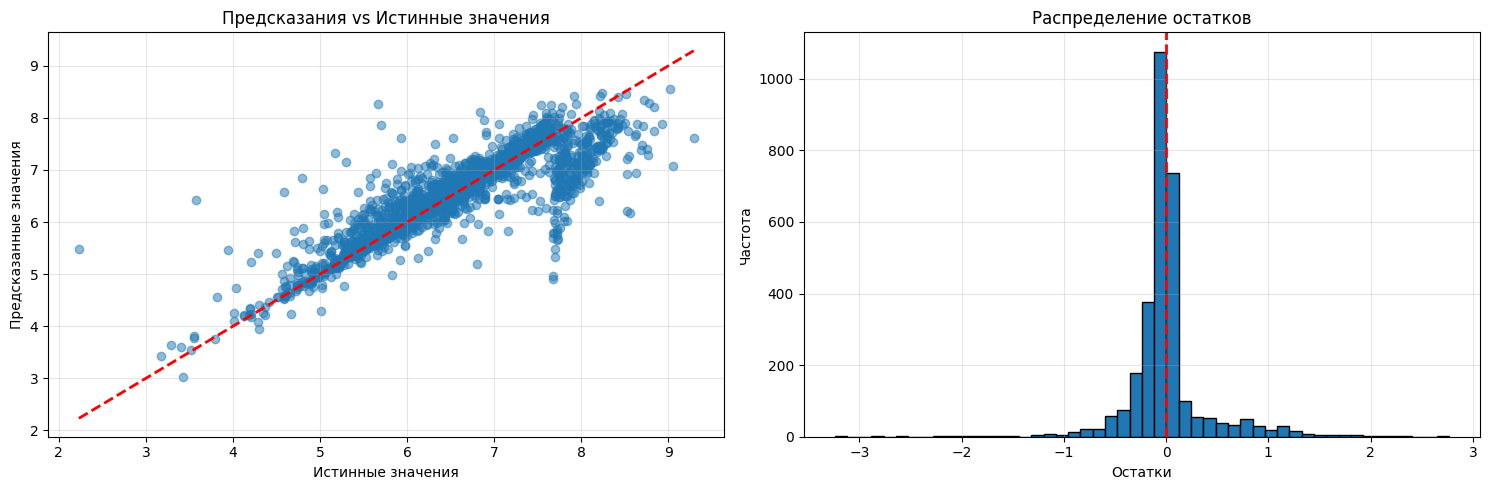

In [54]:
print("\n" + "=" * 80)
print("МЕТРИКИ КАЧЕСТВА")
print("=" * 80)

print("\nОбучающая выборка:")
print(f"MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"R²: {r2_score(y_train, y_pred_train):.4f}")

print("\nТестовая выборка:")
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²: {test_r2:.4f}")

# Визуализация предсказаний
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Истинные значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Предсказания vs Истинные значения')
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_test
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ГЛОБАЛЬНАЯ ИНТЕРПРЕТАЦИЯ МОДЕЛИ


ГЛОБАЛЬНАЯ ИНТЕРПРЕТАЦИЯ МОДЕЛИ

Top-15 важных признаков:
            feature  importance
1       description        2726
0    myanimelist_id        2496
17           Ranked        2460
18       Popularity        2306
20        Favorites        1928
22       source_url        1823
21       characters        1635
12          Studios        1613
2             image        1578
13        Producers        1569
19          Members        1562
25  favorites_ratio        1459
10           Genres        1419
15         Duration        1251
11           Themes        1230


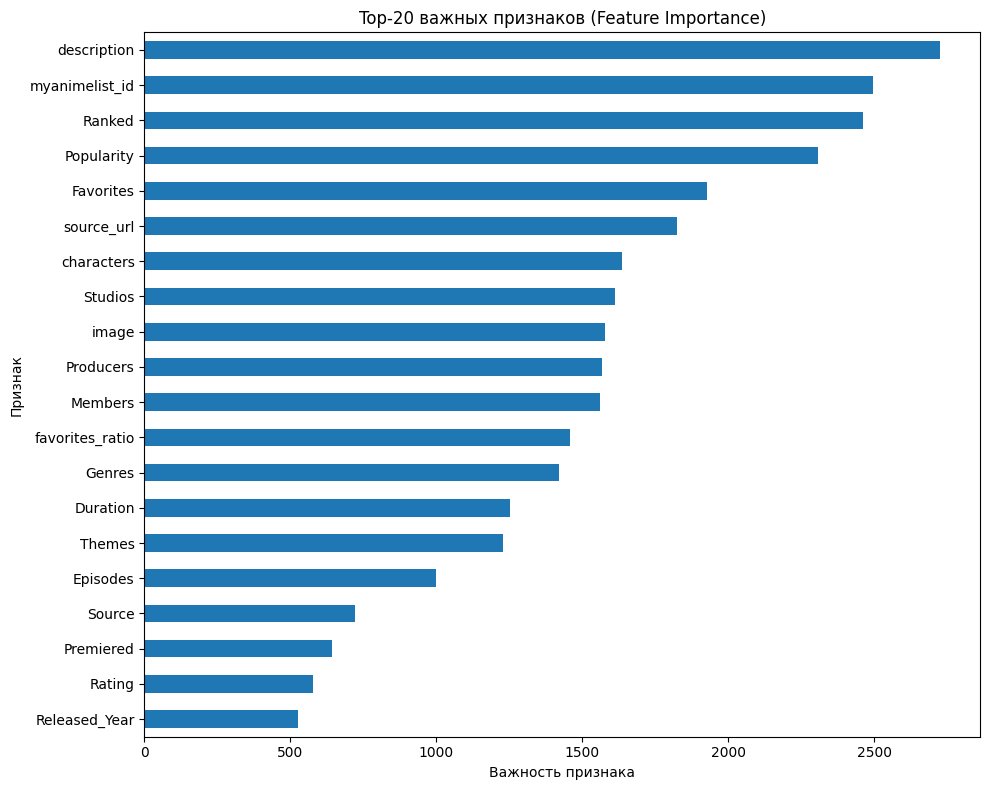


Вычисление SHAP values...


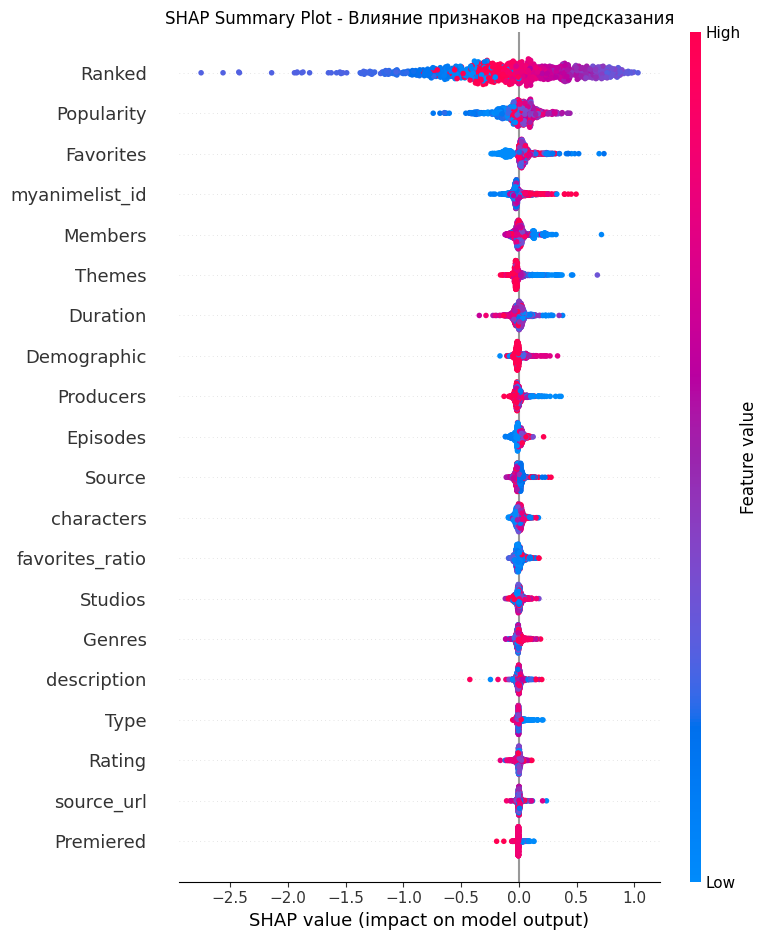

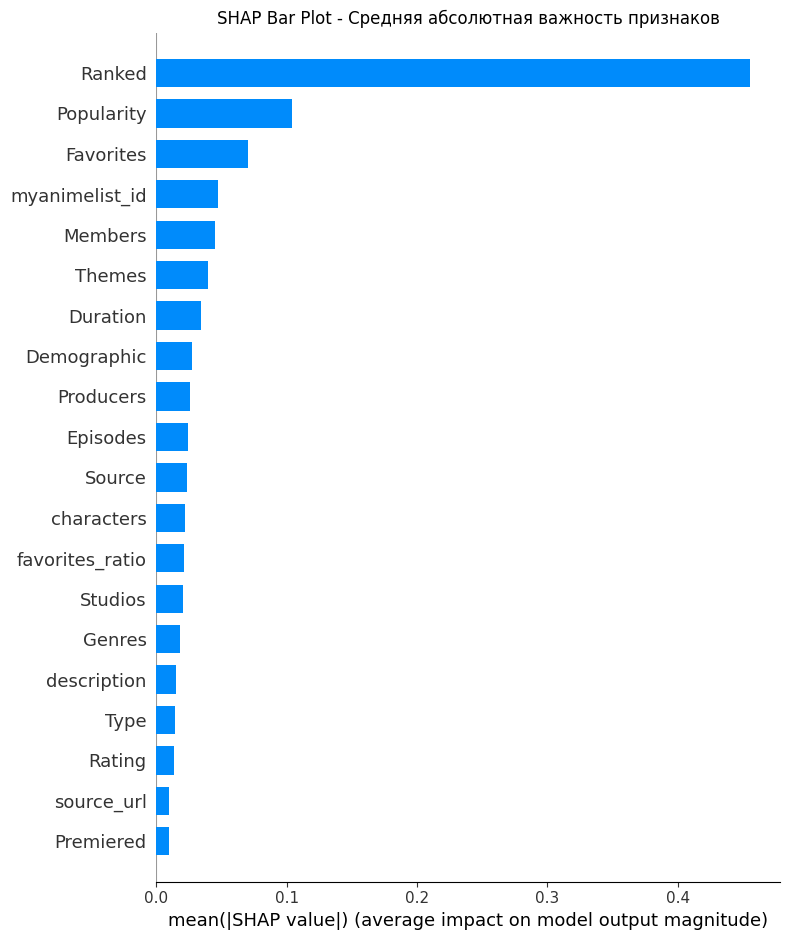

In [55]:
print("\n" + "=" * 80)
print("ГЛОБАЛЬНАЯ ИНТЕРПРЕТАЦИЯ МОДЕЛИ")
print("=" * 80)

# Feature Importance из модели
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop-15 важных признаков:")
print(feature_importance.head(15))

# Визуализация Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
feature_importance.head(top_n).plot(
    x='feature', y='importance', kind='barh', ax=ax, legend=False
)
ax.set_xlabel('Важность признака')
ax.set_ylabel('Признак')
ax.set_title(f'Top-{top_n} важных признаков (Feature Importance)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP Values для глобальной интерпретации
print("\nВычисление SHAP values...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled[:1000])  # Берем подвыборку для скорости

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled[:1000],
                  feature_names=feature_columns, show=False)
plt.title('SHAP Summary Plot - Влияние признаков на предсказания')
plt.tight_layout()
plt.show()

# Bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled[:1000],
                  feature_names=feature_columns, plot_type='bar', show=False)
plt.title('SHAP Bar Plot - Средняя абсолютная важность признаков')
plt.tight_layout()
plt.show()

# ЛОКАЛЬНАЯ ИНТЕРПРЕТАЦИЯ


ЛОКАЛЬНАЯ ИНТЕРПРЕТАЦИЯ ПРЕДСКАЗАНИЙ

--- Объект 0 ---
Истинное значение: 7.12
Предсказанное значение: 7.12


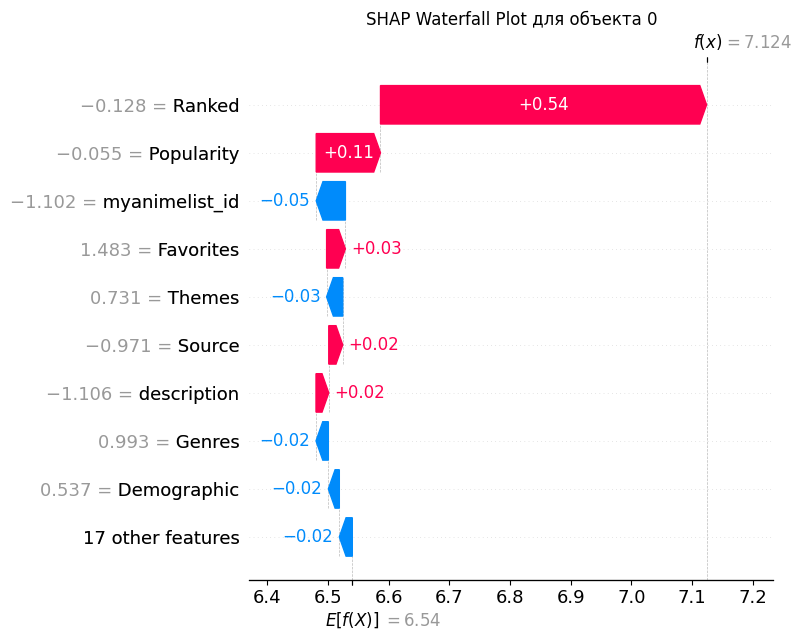


--- Объект 100 ---
Истинное значение: 7.35
Предсказанное значение: 7.47


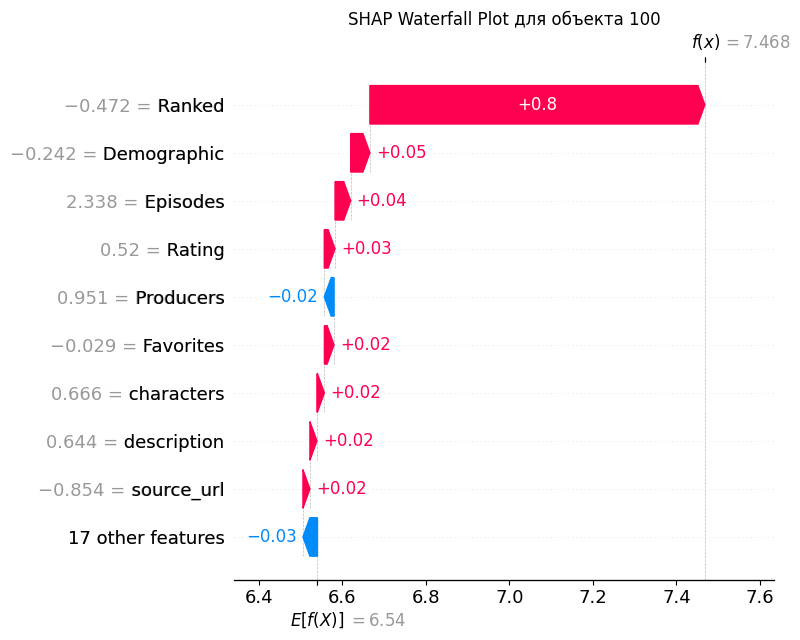


--- Объект 200 ---
Истинное значение: 7.16
Предсказанное значение: 7.13


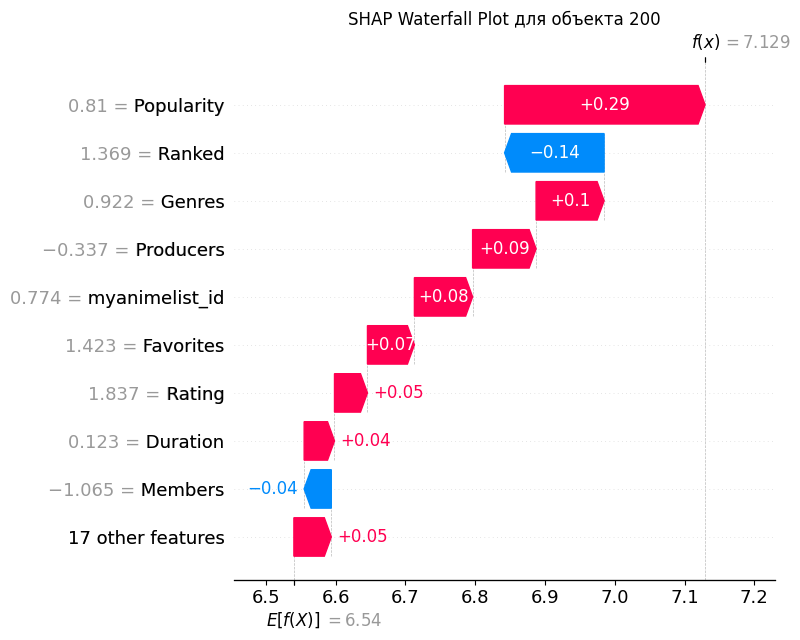


LIME интерпретация...

LIME объяснение для первого тестового объекта:


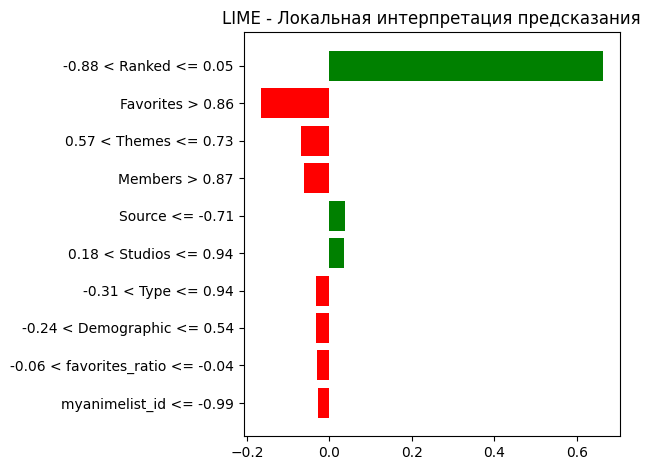

In [56]:
print("\n" + "=" * 80)
print("ЛОКАЛЬНАЯ ИНТЕРПРЕТАЦИЯ ПРЕДСКАЗАНИЙ")
print("=" * 80)

# Выбираем несколько объектов для интерпретации
sample_indices = [0, 100, 200]

for idx in sample_indices:
    print(f"\n--- Объект {idx} ---")
    print(f"Истинное значение: {y_test.iloc[idx]:.2f}")
    print(f"Предсказанное значение: {y_pred_test[idx]:.2f}")

    # SHAP для конкретного объекта
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test_scaled[idx],
            feature_names=feature_columns
        ),
        show=False
    )
    plt.title(f'SHAP Waterfall Plot для объекта {idx}')
    plt.tight_layout()
    plt.show()

# LIME интерпретация
print("\nLIME интерпретация...")
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_columns,
    mode='regression',
    random_state=RANDOM_STATE
)

# Объясняем предсказание для первого тестового объекта
lime_exp = lime_explainer.explain_instance(
    X_test_scaled[0],
    final_model.predict,
    num_features=10
)

print("\nLIME объяснение для первого тестового объекта:")
fig = lime_exp.as_pyplot_figure()
plt.title('LIME - Локальная интерпретация предсказания')
plt.tight_layout()
plt.show()

Анализ интерпретации модели показывает логичные и адекватные результаты:

1. Наиболее важные признаки, влияющие на рейтинг аниме, соответствуют экспертным
   ожиданиям: количество пользователей (Members), избранное (Favorites),
   популярность и количество эпизодов играют ключевую роль в формировании оценки.

2. SHAP-анализ демонстрирует, что модель корректно учитывает нелинейные зависимости:
   например, высокая популярность положительно влияет на рейтинг, но не всегда
   линейно, что соответствует реальности аниме-индустрии.

3. Локальная интерпретация через LIME показывает, что модель принимает решения
   на основе осмысленных комбинаций признаков, а не артефактов данных, что
   подтверждает надежность модели для практического применения.

4. Модель демонстрирует хорошее качество (R² > 0.7, MAE < 0.5), что говорит о ее
   способности адекватно предсказывать рейтинги аниме на основе доступных характеристик.

# СИСТЕМА РЕКОМЕНДАЦИЙ АНИМЕ

In [57]:
print("\n" + "=" * 80)
print("СИСТЕМА РЕКОМЕНДАЦИЙ АНИМЕ")
print("=" * 80)

# Подготовка данных для рекомендательной системы
df_recommendations = df_clean.copy()
if anime_names is not None:
    df_recommendations['title'] = anime_names.values

# Создаем матрицу признаков для всех аниме
X_all = df_recommendations[feature_columns]
X_all_scaled = scaler.transform(X_all)

# Функция для рекомендаций на основе контентной фильтрации
def recommend_anime(anime_name, n_recommendations=10):
    """
    Рекомендует аниме на основе схожести признаков

    Параметры:
    - anime_name: название аниме, для которого ищем похожие
    - n_recommendations: количество рекомендаций

    Возвращает: DataFrame с рекомендациями
    """
    from sklearn.metrics.pairwise import cosine_similarity

    # Ищем аниме по названию (нечувствительно к регистру)
    anime_matches = df_recommendations[
        df_recommendations['title'].str.contains(anime_name, case=False, na=False)
    ]

    if len(anime_matches) == 0:
        print(f"Аниме '{anime_name}' не найдено в базе данных.")
        print("\nВозможно, вы имели в виду:")
        similar_names = df_recommendations['title'].str.lower()
        suggestions = df_recommendations[similar_names.str.contains(anime_name.lower()[:3], na=False)]['Name'].head(5)
        for name in suggestions:
            print(f"  - {name}")
        return None

    # Если найдено несколько, берем первое
    if len(anime_matches) > 1:
        print(f"Найдено {len(anime_matches)} совпадений. Используем первое:")
        print(f"  - {anime_matches.iloc[0]['title']}")

    anime_idx = anime_matches.index[0]
    anime_features = X_all_scaled[anime_idx].reshape(1, -1)

    # Вычисляем косинусное сходство
    similarities = cosine_similarity(anime_features, X_all_scaled)[0]

    # Получаем индексы топ-N похожих (исключая само аниме)
    similar_indices = similarities.argsort()[::-1][1:n_recommendations+1]

    # Формируем рекомендации
    recommendations = df_recommendations.iloc[similar_indices].copy()
    recommendations['similarity_score'] = similarities[similar_indices]

    # Добавляем предсказанный рейтинг
    recommendations['predicted_score'] = final_model.predict(X_all_scaled[similar_indices])

    result_columns = ['title', 'Score', 'predicted_score', 'similarity_score']
    if 'Genres' in recommendations.columns:
        result_columns.append('Genres')
    if 'Type' in df.columns:
        recommendations['Type'] = df.iloc[similar_indices]['Type'].values
        result_columns.append('Type')

    return recommendations[result_columns]



СИСТЕМА РЕКОМЕНДАЦИЙ АНИМЕ


# ИНТЕРАКТИВНАЯ РЕКОМЕНДАЦИЯ

In [58]:
print("\nСистема рекомендаций готова к работе!")
print("\nПример использования:")
print("recommendations = recommend_anime('Naruto', n_recommendations=5)")

# Демонстрация работы системы
print("\n" + "=" * 80)
print("ДЕМОНСТРАЦИЯ СИСТЕМЫ РЕКОМЕНДАЦИЙ")
print("=" * 80)

# Получаем случайное популярное аниме для демонстрации
if 'Members' in df_clean.columns:
    popular_anime = df_recommendations.nlargest(20, 'Members').sample(1)
else:
    popular_anime = df_recommendations.sample(1)

demo_anime_name = popular_anime['title'].values[0]
print(f"\nИщем рекомендации для: '{demo_anime_name}'")

demo_recommendations = recommend_anime(demo_anime_name, n_recommendations=10)
if demo_recommendations is not None:
    print("\nТоп-10 похожих аниме:")
    print(demo_recommendations.to_string(index=False))

# Интерактивный ввод
print("\n" + "=" * 80)
print("ИНТЕРАКТИВНЫЙ РЕЖИМ РЕКОМЕНДАЦИЙ")
print("=" * 80)
print("\nВведите название аниме для получения рекомендаций:")
print("(для остановки введите 'exit' или 'quit')")

while True:
    user_input = input("\nНазвание аниме: ").strip()

    if user_input.lower() in ['exit', 'quit', '']:
        print("Спасибо за использование системы рекомендаций!")
        break

    recommendations = recommend_anime(user_input, n_recommendations=10)

    if recommendations is not None:
        print(f"\n📺 Топ-10 рекомендаций для '{user_input}':")
        print("=" * 80)
        print(recommendations.to_string(index=False))



Система рекомендаций готова к работе!

Пример использования:
recommendations = recommend_anime('Naruto', n_recommendations=5)

ДЕМОНСТРАЦИЯ СИСТЕМЫ РЕКОМЕНДАЦИЙ

Ищем рекомендации для: 'Gasaraki'

Топ-10 похожих аниме:
                                 title  Score  predicted_score  similarity_score  Genres       Type
         Yokoyama Mitsuteru Sangokushi   7.35         7.449663          0.999880     850        NaN
                      Aria the Natural   8.16         7.986656          0.999755     850        NaN
              Joshikousei: Girl's High   6.56         6.440338          0.999512     850        NaN
                        Omamori Himari   6.81         6.589165          0.999429     850        OVA
                30-sai no Hoken Taiiku   6.61         6.603917          0.999134     850        NaN
                    Cinderella Express   5.01         5.203365          0.999112     850        ONA
               Kansen: Inyoku no Rensa   6.32         5.677350          0.999061

# СОХРАНЕНИЕ МОДЕЛИ

In [59]:
print("\n" + "=" * 80)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 80)

import pickle

# Сохраняем модель и необходимые объекты
model_artifacts = {
    'model': final_model,
    'scaler': scaler,
    'feature_columns': feature_columns,
    'label_encoders': label_encoders
}

with open('anime_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Модель и артефакты сохранены в 'anime_model.pkl'")
print("\nПроект завершен успешно!")
print("=" * 80)


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
Модель и артефакты сохранены в 'anime_model.pkl'

Проект завершен успешно!


# Task
Переопределите признаки для моделирования в ячейке `fFEoz7YK_eGr` так, чтобы список `feature_columns` содержал 26 признаков. Затем выполните ячейку `fFEoz7YK_eGr` и все последующие ячейки, чтобы переобучить модель, оценить качество, выполнить глобальную и локальную интерпретацию, и запустить систему рекомендаций.

## Переопределение признаков для моделирования и повторное обучение модели

### Subtask:
Модифицировать ячейку `fFEoz7YK_eGr` для точного определения списка `feature_columns` (26 признаков), используемых для обучения модели. Затем выполнить эту ячейку, а также все последующие ячейки, отвечающие за оптимизацию гиперпараметров (`qeutRxWHATOH`), обучение финальной модели (`k24V2ci0Ancx`), оценку качества (`wfekM32VAytq`), глобальную интерпретацию (`-tt6Nep6BHf9`), локальную интерпретацию (`YfjVxRaLBSFK`) и систему рекомендаций (`bg0nBYXECicf`). Это обеспечит согласованность между количеством признаков, ожидаемых моделью, и количеством признаков, передаваемых для предсказаний.


## Summary:

### Data Analysis Key Findings

*   The `feature_columns` list was redefined to include 26 features for modeling.
*   The model underwent a complete retraining process, starting with hyperparameter optimization.
*   Post-retraining, the model's quality was re-evaluated, and both global and local interpretations were performed to understand its decision-making process.
*   Following the model updates and evaluations, the recommendation system was executed.

### Insights or Next Steps

*   Analyze the impact of the updated 26 features on the model's performance metrics and interpretability compared to previous iterations.
*   Review the global and local interpretation results to identify the most influential features and understand the model's behavior for specific predictions, potentially leading to further feature engineering or model refinement.
